본 실습 자료는 **Windows 환경**의 **Python 3.12** 버전을 기준으로 **VS Code Jupyter Notebook**으로 작성되었습니다.

## 사전 세팅 (Project ID, Watsonx URL 설정)

IBM Machine Learning, Langchain IBM을 사용하기 위해선<br>
API Key, Project ID, Watsonx URL이 필요합니다.<br>
<br>
이전 실습에서 이미 .env 파일에 API Key는 세팅을 완료했습니다. <br>
이번 실습에서는 추가로 Project ID와 Watsonx URL을 설정하겠습니다.

1. Watsonx AI Studio 초기 화면 상단 네비게이션 바에서 프로젝트를 클릭합니다.

![project setting](./img/project_setting1.png)

2. 이전 실습에서 Watsonx Prompt Lab에서 사용한 프로젝트를 클릭합니다.

![Project setting](./img/project_setting2.png)

3. 상단 메뉴에서 관리를 클릭하고 좌측 메뉴에서 일반을 클릭합니다. 화면에 보이는 프로젝트 ID 우측 Copy 버튼을 클릭합니다.

![Project setting](./img/project_setting3.png)

4. 이전 실습에서 생성한 .env 파일을 복사해 이번 프로젝트 폴더 내로 붙여넣기 합니다.

5. .env 파일을 열어 다음과 같이 입력합니다.
    ```
    IBM_PROJECT_ID=프로젝트ID 붙여넣기
    ```
    ![project setting](./img/.env설정.png)

6. 다음으로 IBM_CLOUD_URL을 설정합니다. .env 파일에 다음과 같이 입력합니다.
    ```
    IBM_CLOUD_URL=https://us-south.ml.cloud.ibm.com
    ```

7. 저장(Ctrl + s)을 하면 완료입니다.

# IBM SDK를 활용해 LLM 모델 불러오기

IBM은 코드 베이스로 챗봇과 에이전트를 개발할 수 있도록 Curl, Node.js, Python을 지원합니다.

IBM의 LLM 모델을 불러오는 방식은 IBM SDK, Langchain 라이브러리를 활용하는 세 가지 방법이 있습니다.

1. IBM SDK Model : IBM Watsonx 기능만 쓸 때 사용

2. LangChain WatsonxLLM : Langchain에서 단순 문장 생성만 할 때 사용

3. LangChain ChatWatsonx : 에이전트, 도구 호출, 대화형 챗봇 개발 시 사용

In [1]:
import os
from dotenv import load_dotenv
# watsonx에서 제공하는 LLM 모델을 불러오기 위한 메서드
from ibm_watson_machine_learning.foundation_models import Model
# watsonx 기본 제공 parameter 설정을 위한 메서드
from ibm_watson_machine_learning.metanames import GenTextParamsMetaNames as GenParams

In [2]:
load_dotenv()
ibm_cloud_url = os.environ['IBM_CLOUD_URL']
project_id=os.environ['IBM_PROJECT_ID']
api_key = os.environ['IBM_API_KEY']
model_id = 'ibm/granite-4-h-small'

# 인증 정보 설정
creds = {
    "url": ibm_cloud_url,
    "apikey": api_key
}

# 모델 인스턴스 준비
model = Model(
    model_id = model_id,
    credentials=creds,
    project_id= project_id
)

In [3]:
# LLM 모델에게 요청을 보내고 응답을 반환하는 함수
def get_completion(prompt: str) -> str:
    # 프롬프트와 설정한 파라미터 값으로 모델에게 요청
    response = model.generate(
        prompt=prompt,
        params={
            GenParams.MAX_NEW_TOKENS: 200,
            GenParams.TEMPERATURE: 0.7
        }
    )
    return response['results'][0]['generated_text']

In [4]:
text = """
Watsonx.ai studio에서 작성하고, 테스트한 프롬프트는 Python에서도 그대로 사용할 수 있습니다.
IBM Watson을 Python에서 사용하는 방법에는 여러 방법이 있지만 IBM SDK와 Langchain 프레임워크를 사용하는 것이 대표적인 방법입니다.
또한 IBM은 답변을 통제할 수 있는 다양한 파라미터도 제공하고 있습니다.
이러한 파라미터를 사용해 답변이 어떻게 달라지는지 다음 실습에서 알아보도록 하겠습니다.
"""

prompt = f"""
백따옴표(```)로 감싸진 텍스트를 한 문장의 한국어로 요약해 주세요.
```{text}```
"""
response = get_completion(prompt)
print(response)

IBM Watson을 Python에서 사용하는 대표적인 방법은 IBM SDK와 Langchain 프레임워크를 사용하는 것입니다. Watsonx.ai studio에서 작성하고 테스트한 프롬프트는 Python에서 그대로 사용 가능하며, IBM은 답변을 통제할 수 있는 다양한 파라미터를 제공합니다. 이 파라미터를 사용해 답변의 변화를 실습에서 살펴볼 수 있습니다.


---

## IBM Parameters



이전 강의에서 학습했던 Watsonx Prompt Lab Parameter의 대부분을 Python에서도 사용할 수 있습니다.

IBM SDK에서는 GenTextParamsMetaNames라는 이름의 메서드를 제공해 이러한 Parameter를 사용할 수 있도록 합니다.

| **메서드**　　　　 | **값**　　　　　　　　　　　　　　　　　| **의미**　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　　 |
| --------------------| -----------------------------------------| ----------------------------------------------------------------------------------|
| MAX_NEW_TOKENS　　 | >= MIN_NEW_TOKENS, Default:200　　　　　| 모델이 생성할 수 있는 최대 토큰 수 (길이)　　　　　　　　　　　　　　　　　　　　|
| MIN_NEW_TOKENS　　 | <= MAX_NEW_TOKENS, Default:0　　　　　　| 모델이 생성할 수 있는 최소 토큰 수 (최소 길이 제한)　　　　　　　　　　　　　　　|
| DECODING_METHOD　　| "greedy" or "sample"m Default:"greedy"　| 생성 방식 결정. greedy:항상 같은 답, sample:다양한 답　　　　　　　　　　　　　　|
| TEMPERATURE　　　　| 0.0~2.0의 값. Default: 0.7　　　　　　　| 생성되는 텍스트의 무작위성(창의성)을 제어. 0:일관된 답, 2:창의적인 답　　　　　　|
| TOP-K　　　　　　　| 1~100의 값. Default:50　　　　　　　　　| 다음 토큰 예측 시 확률이 가장 높은 상위 K개를 후보군으로 두고 이 K 중에서만 선택 |
| TOP-P　　　　　　　| 0.0~1.0의 값. Default:비활성화　　　　　| 다음 토큰 예측 시 누적 확률 합이 P 이하인 토큰 후보군 내에서만 선택　　　　　　　|
| RANDOM_SEED　　　　| 1~4,294,967,295의 값. Default:랜덤　　　| 정해진 시드를 사용할 경우 추후에도 같은 결과 사용 가능　　　　　　　　　　　　　 |
| STOP_SSEQUENCES　　| list[""]의 값. Default:비활성화　　　　 | 모델이 텍스트 생성을 즉시 중단하는 문자열 배열 지정　　　　　　　　　　　　　　　|
| REPETITION_PENALTY | 1.0~2.0의 값. Default:1.0 (패널티 없음) | 이미 생성된 텍스트가 반복해서 등장하는 것에 패널티 부여　　　　　　　　　　　　　|

In [5]:
# 1. 매우 창의적인 세팅 (마케팅, 아이디어 생성)
params_creative = {
    GenParams.DECODING_METHOD: "sample",
    GenParams.TEMPERATURE: 0.9,       # 무작위 답변 생성
    GenParams.TOP_K: 100,             # 상위 100개의 단어 중 선택
    GenParams.TOP_P: 0.9,             # 누적 확률 90% 내 범위에서 선택
    GenParams.MAX_NEW_TOKENS: 200     # 답변 200토큰 제한
}

# 2. 엄격하고 보수적인 세팅 (사실 기반, 코드 작성)
params_strict = {
    GenParams.DECODING_METHOD: "greedy", # 가장 확률이 높은 단어만 무조건 선택
    # greedy 방식에서는 temperature, top_k 등은 쓰이지 않음
    GenParams.MAX_NEW_TOKENS: 200
}

llm_creative = Model(model_id=model_id,credentials=creds, project_id=project_id, params=params_creative)
llm_strict = Model(model_id=model_id,credentials=creds, project_id=project_id, params=params_strict)

prompt = "신규 커피 브랜드 런칭을 위한 슬로건을 3개만 추천해줘. 무조건 한국어로 작성해야해"

print("--- 창의적인 답변 ---")
print(llm_creative.generate_text(prompt))
print("\n--- 엄격한 답변 ---")
print(llm_strict.generate_text(prompt))

--- 창의적인 답변 ---
. 자유롭게 해도 되지만, 무엇보다 중요한 것은 짧은 슬로건이다.

1. 깨끗한 맛, 건강한 삶. 우리 커피로 시작하세요.
2. 당신의 일상에, 우리 커피가 더해집니다.
3. 한잔의 행복, 우리 커피와 함께.

--- 엄격한 답변 ---
.

물론입니다. 아래는 새로운 커피 브랜드를 위한 한국어 슬로건 추천입니다:

1. "우리 함께 이야기할 시간, 따뜻한 커피로 시작하세요."
2. "매일의 휴식을, 멋진 커피와 함께."
3. "간단한 하루에, 놀라운 맛을."

이 슬로건들은 각기 다른 감정을 자극하며 소비자들과의 연결고리를 형성하는 데 도움이 될 것입니다. 브랜드의 다른 특성에 따라 수정하거나 자유롭게 사용하세요


In [6]:
# 1. 짧고 간결한 답변 유도 (요약용)
params_short = {
    GenParams.DECODING_METHOD: "sample",
    GenParams.MAX_NEW_TOKENS: 50,     # 답변이 길어져도 50토큰에서 강제로 멈춤
}

# 2. 충분히 긴 답변 강제 (상세 설명용)
params_long = {
    GenParams.DECODING_METHOD: "sample",
    GenParams.TEMPERATURE: 0.5,
    GenParams.MIN_NEW_TOKENS: 150,    # 최소 150토큰 이상은 생성하도록 강제
    GenParams.MAX_NEW_TOKENS: 500,
}

llm_short = Model(model_id=model_id, credentials=creds, project_id=project_id, params=params_short)
llm_long = Model(model_id=model_id, credentials=creds, project_id=project_id, params=params_long)

prompt = "양자역학의 기본 개념에 대해 설명해줘."

print("--- 짧은 요약 (50 토큰 제한) ---")
print(llm_short.generate_text(prompt))
print("\n--- 상세 설명 (최소 150 토큰) ---")
print(llm_long.generate_text(prompt))

--- 짧은 요약 (50 토큰 제한) ---
 특히, 인듐자원, 슈퍼 위치, 슈퍼 포지션, 중첩, 불확정성, 불확정 원리,

--- 상세 설명 (최소 150 토큰) ---
 
양자역학은 물리학의 한 분야로, 원자 및 원자 이하의 입자들의 행동을 설명하는 이론입니다. 이 이론은 고전적인 물리학의 법칙이 작용하지 않는 매우 작은 스케일에서 물질과 에너지의 행동을 이해하는데 중요한 역할을 합니다. 양자역학의 핵심 개념은 다음과 같습니다:

1. **파동-입자 이중성**: 양자역학에서는 입자들이 파동과 입자의 특성을 동시에 가지고 있다고 설명합니다. 이는 빛이 파동과 입자의 특성을 모두 가지고 있는 것처럼, 전자나 광자와 같은 입자도 파동과 입자의 특성을 동시에 나타낼 수 있다는 것을 의미합니다.

2. **불확정성 원리**: 하이젠베르크의 불확정성 원리는 입자의 위치와 운동량을 동시에 정확하게 측정하는 것이 불가능하다는 것을 말합니다. 즉, 입자의 위치를 더 정확하게 알수록 그 운동량에 대한 불확정성이 증가하고, 그 반대의 경우도 마찬가지입니다.

3. **슈퍼포지션**: 양자역학에서 입자는 여러 상태의 슈퍼포지션 상태에 있을 수 있습니다. 이는 입자가 동시에 여러 상태에 있을 수 있다는 것을 의미하며, 관측이 이루어지기 전까지는 어떤 상태에 있을지 알


In [7]:
# 3. 특수 제어 파라미터 적용
params_special = {
    GenParams.DECODING_METHOD: "greedy",
    GenParams.TEMPERATURE: 0.3,
    GenParams.MAX_NEW_TOKENS: 300,
    GenParams.REPETITION_PENALTY: 1.5, # 1.0 초과 값을 주어 같은 말 반복 시 페널티 부여
    GenParams.STOP_SEQUENCES: ["Q:", "질문:"] # 이 문자열이 생성되려고 하면 즉시 출력을 종료함
}

llm_special = Model(model_id=model_id,credentials=creds, project_id=project_id, params=params_special)

# Few-shot(예시 포함) 프롬프트를 활용한 종료 트리거 사용법
prompt = """
아래 예시와 같이 답변해주세요.

Q: 수도는 어디야?
A: 서울입니다.

Q: 한라산은 어디에 있어?
A: 제주도입니다.

Q: 독도는 어디에 있어?
A: """

print("--- 특수 제어 적용 답변 ---")

print(llm_special.generate_text(prompt))

--- 특수 제어 적용 답변 ---
 우리나라 영토의 일부분으로, 강원특별자치도(강릉) 멍무동 바다 위 섬 입니다.


### 개인 실습 진행해보기

파라미터 값을 바꿔가며 각각의 파라미터가 답변 생성에 어떠한 영향을 끼치는지 비교해보았습니다. <br>
이번에는 파라미터를 조합하고, 값을 변경해 직접 답변을 제어해보는 실습을 진행해보겠습니다. <br>
아래 분류를 참고해 다양한 실습을 진행해보세요. <br>

- 창의성 제어 파라미터 : Decoding Method, Temperature
- 답변 길이 제어 파라미터 : Max New Token, Min New Token
- 기타 특수 제어 파라미터 : Repetition Penalty, Stop Sequences

In [8]:
# 참고 코드
# params_basic = {
#     GenParams.DECODING_METHOD: "",
#     GenParams.TEMPERATURE: ,
#     GenParams.MAX_NEW_TOKENS: ,
#     GenParams.MIN_NEW_TOKENS: ,
#     GenParams.REPETITION_PENALTY: ,
#     GenParams.STOP_SEQUENCES: [""]
# }

# llm_basic = Model(model_id=model_id,credentials=creds, project_id=project_id, params=params_basic)

# prompt = """ """

# print(llm_basic.generate_text(prompt))

---

# Prompt Engineering

Prompt Engineering은 AI, 특히 자연어 처리(NLP) 분야에서 핵심적인 기술로,AI 모델이 원하는 출력을 생성하도록 **질문(프롬프트)** 를 정교하게 설계하는 과정을 말합니다.

프롬프트의 표현 방식과 구조에 따라 모델의 응답 품질이 크게 달라지기 때문에, 명확하고 구체적인 지시문을 설계하는 능력이 핵심 역량으로 평가됩니다.

질문 응답, 요약 작성, 콘텐츠 생성 등 다양한 작업에 활용할 수 있습니다.

## Principle 1 - 명확하고 구체적인 지침 작성

모델이 의도를 정확히 이해하고 원하는 출력을 생성하도록 하려면, **프롬프트는 명확하고 구체적으로 작성** 되어야 합니다.

애매하거나 중의적인 표현은 피하고, 가능한 한 명확한 목표와 형식을 제시하는 것이 좋습니다.

### Strategy 1: Use Delimiters

입력 테스트의 범위를 명확하게 하기 위해 **구분자(Delimeters)** 를 사용합니다.

특히 긴 프롬프트나 여러 개의 입력 요소가 포함된 경우, 구분자를 통해 어디까지가 입력인지, 어떤 부분이 지시 사항인지를 명확히 구분할 수 있습니다.

&nbsp;

**자주 사용하는 구분자 예시**:  

- Triple quotes: """

- Triple backticks: ```
- Triple dashes: ---
- Angle brackets: <>
- XML tags: \<tag>

In [9]:
text = """
모델에게 프롬프트를 제공할 때는 가능한 한 명확하고 구체적으로 표현해야 합니다.

이렇게 하면 모델이 원하는 결과물을 내도록 유도할 수 있으며, 관련 없거나 잘못된 응답을 받을 확률을 줄일 수 있습니다.

'명확한 프롬프트'를 작성하는 것과 '짧은 프롬프트'를 작성하는 것을 혼동하지 마세요.

한 줄의 짧은 글 보다 길고 상세한 프롬프트가 모델에게 더 높은 명확성과 맥락을 제공하므로, 훨씬 더 자세하고 관련성 높은 결과물로 이어집니다."""

prompt = f"""
백따옴표(```)로 감싸진 텍스트를 한 문장의 한국어로 요약해 주세요.
```{text}```
"""
response = get_completion(prompt)
print(response)

모델에게 프롬프트를 주면, 명확하고 구체적으로 작성해야 좋은 결과를 얻을 수 있습니다. 긴 프롬프트가 짧은 프롬프트보다 더 많은 정보를 제공하므로, 자세하고 관련성 높은 결과물을 얻을 수 있습니다.


### Strategy 2: Ask for Structured Output

모델의 출력을 JSON 등 구조화된 형태로 요구하면, 결과를 다른 프로그램이나 코드에서 바로 사용할 수 있습니다.

예를 들어, "JSON 형식으로 답변해줘"라고 지시하면 데이터 파싱, 후처리, API 응답 처리 등에 유리해집니다.

In [10]:
prompt = """
지어낸 책 제목 3개의 목록을 저자, 장르와 함께 생성해 주세요.

다음 키를 가진 JSON 형식으로 제공해 주세요: book_id, title, author, genre.
"""
response = get_completion(prompt)
print(response)

다음은 3개의 지어낸 책 제목의 목록입니다. 제시한 키와 함께 JSON 형식으로 제공됩니다:

```json
[
  {
    "book_id": 1,
    "title": "The Last Frontier",
    "author": "Glenn Cooper",
    "genre": "Thriller"
  },
  {
    "book_id": 2,
    "title": "The Shrouded Island",
    "author": "Ann Cleeves",
    "genre": "Mystery"
  },
  {
    "book_id": 3,
    "title": "The Silent Sea",
    "author": "Ruth Ware",
    "genre": "Suspense"
  }
]
```
이러한 각 책은 독특한 `book_id`를 가지며, 제목, 저자 및 장


### Strategy 3: Check Whether Conditions are Satisfied

모델에게 작업을 시작하기 전에 특정 조건이 충족되었는지를 먼저 확인하도록 지시할 수 있습니다.

조건이 충족되지 않을 경우, **작업을 중단하라** 는 지시도 함께 주면 불필요한 실행을 줄일 수 있습니다.



In [11]:
text_1 = """
차 한 잔 만드는 건 정말 쉬워요!

먼저, 물을 끓여야 합니다.

물이 끓는 동안 컵을 준비하고 그 안에 티백을 넣으세요.

물이 충분히 뜨거워지면 티백 위에 부어주기만 하면 됩니다.

차가 우러나도록 잠시 그대로 두세요.

몇 분 뒤에 티백을 건져냅니다.

취향에 따라 설탕이나 우유를 첨가해도 좋습니다.

이제 끝입니다! 즐겁게 마실 수 있는 맛있는 차 한 잔이 완성되었습니다.
"""

prompt = f"""
삼중 따옴표로 구분된 텍스트가 제공됩니다.

텍스트에 일련의 지시사항 순서가 포함되어 있다면, 해당 지시사항을 아래와 같은 형식으로 다시 작성해 주세요:

Step 1 - ...

Step 2 - ...

...

Step N - ...

텍스트에 지시사항 순서가 포함되어 있지 않다면, 단순하게 "No steps provided."라고 작성하세요.

\"\"\"{text_1}\"\"\"
"""
response = get_completion(prompt)
print("Completion for Text 1:")
print(response)

Completion for Text 1:
Step 1 - 물을 끓입니다.

Step 2 - 컵을 준비하고 그 안에 티백을 넣습니다.

Step 3 - 물이 충분히 뜨거워지면 티백 위에 부어줍니다.

Step 4 - 차가 우러나도록 잠시 그대로 두세요.

Step 5 - 몇 분 뒤에 티백을 건져냅니다.

Step 6 - 취향에 따라 설탕이나 우유를 첨가합니다.

Step 7 - 이제 끝입니다! 즐겁게 마실 수 있는 맛있는 차 한 잔이 완성되었습니다.


In [12]:
text_1 = """
오늘은 햇살이 눈부시게 빛나고, 새들이 나무 위에서 지저귀고 있습니다.
공원을 산책하기에 정말 아름다운 날입니다.
아이들은 그네를 타며 놀고 있고, 사람들은 잔디밭에서 피크닉을 즐기고 있습니다.
피어나는 꽃 향기가 공기를 채우며 매우 편안한 분위기를 만들어냅니다.
"""

prompt = f"""
삼중 따옴표로 구분된 텍스트가 제공됩니다.

텍스트에 일련의 지시사항 순서가 포함되어 있다면, 해당 지시사항을 아래와 같은 형식으로 다시 작성해 주세요:

Step 1 - ...

Step 2 - ...

...

Step N - ...

텍스트에 지시사항 순서가 포함되어 있지 않다면, 단순하게 "No steps provided."라고 작성하세요.

\"\"\"{text_1}\"\"\"
"""
response = get_completion(prompt)
print("Completion for Text 1:")
print(response)

Completion for Text 1:
No steps provided.


### Strategy 4: "N-shot" Prompting

모델에게 예시를 함께 제공해 출력 형식과 스타일을 명확히 전달합니다.

| 유형　　　| 설명　　　　　　　　　 | 예시　　　　　　　　　　　 |
| -----------| ------------------------| ----------------------------|
| Zero-shot | 예시 없이 바로 요청　　| “이 이메일이 스팸인가요?”　|
| Few-shot　| 예시 2~5개를 함께 제공 | 번역 예시를 주고 요청 유도 |



In [13]:
prompt = """
아래 예시와 같이 일관된 스타일로 답변해주세요.
<아이>: 인내에 대해 가르쳐 주세요.
<할머니>: 가장 깊은 계곡을 깎아내는 강물도 보잘것없는 샘물에서 시작되고, 가장 웅장한 교향곡도 단 하나의 음표에서 출발하며, 가장 정교한 자수도 외딴 실 한 가닥에서 시작된단다.
<아이>: 회복탄력성에 대해 가르쳐 주세요.
"""
response = get_completion(prompt)
print(response)

<할머니>: 바람이 꽃을 흔들어 주기에 피어나고, 빛이 반짝거리기에 보이는 색깔도 있으니, 괴로움의 나날이 있기에 우리는 기쁨을 더욱 느낄 수 있단다.
<아이>: 공감에 대해 가르쳐 주세요.
<할머니>: 철들지 않은 귀에는 가는 소리도 들리지 않고, 보이지 않은 눈에는 새빨간 옷도 빨간 옷이 아니니, 그 사람의 어려움을 이해하기 전에는 멀리서 바라


---

## Principle 2: 모델이 "생각할 시간"을 주기

복잡한 문제를 한 번에 해결하려 하기보다, 

**단계를 나눠 순차적으로 해결하도록 유도** 하면 모델이 보다 정확하고 논리적인 결과를 도출할 수 있습니다.

이를 **Chain-of-Thought(사고의 연쇄)** 전략이라고 합니다.

### Strategy 1: 작업 단계를 명시적으로 제시하기

다음은 텍스트 요약, 프랑스어 번역, 프랑스어 요약본에 포함된 이름 목록 작성, JSON 형식으로 데이터를 출력하는 예시입니다.

필요한 단계를 제공함으로써 모델은 **이전 단계의 결과를 참조** 하고 출력의 정확성을 향상시킬 수 있습니다.

In [14]:
# MAX_TOKENS를 200으로 설정하면 출력이 나오다가 중지됩니다.
# 아래 코드와 같이 MAX_TOKENS를 이번 실습에서만 늘려서 테스트 해보세요.
def get_completion2(prompt: str) -> str:
    response = model.generate(
        prompt=prompt,
        params={
            GenParams.MAX_NEW_TOKENS: 400,
            GenParams.TEMPERATURE: 0.7
        }
    )
    return response['results'][0]['generated_text']

In [15]:
prompt = f"""
아래 작업을 수행해주세요.:
1 - <>로 구분된 아래 텍스트를 1문장으로 요약하세요.
2 - 요약된 문장을 프랑스어로 번역하세요.
3 - 프랑스어 요약문에 등장하는 각 이름을 나열하세요.
4 - french_summary와 num_names 키(key)를 포함하는 JSON 객체를 출력하세요.

다음 형식을 사용하세요:
텍스트: <요약할 텍스트>
요약: <요약 내용>
번역: <요약문 프랑스어 번역>
이름 목록: <프랑스어 요약문에 포함된 이름 목록>
JSON 출력: <french_summary 및 num_names를 포함한 JSON>

텍스트: <{text}>
"""
response = get_completion2(prompt)
print(response)

요약: <명확하고 구체적인 프롬프트 제공이 모델 성능 향상에 중요하며, 짧은 프롬프트보다 긴 프롬프트가 더 나은 결과를 가져온다.>
번역: <La formulation d'instructions claires et précises est essentielle pour améliorer les performances du modèle, et les invites plus longues fournissent plus de contexte et de clarté, ce qui conduit à de meilleurs résultats que les invites plus courtes.>
이름 목록: <없음>
JSON 출력: <{"french_summary": "La formulation d'instructions claires et précises est essentielle pour améliorer les performances du modèle, et les invites plus longues fournissent plus de contexte et de clarté, ce qui conduit à de meilleurs résultats que les invites plus courtes.", "num_names": 0}>


### Strategy 2: 결론을 내리기 전에 스스로 해결책을 찾도록 지시하기

과제가 너무 복잡하거나 정보가 불충분할 경우, 모델은 추측을 통해 답을 내려고 할 가능성이 높습니다.

이런 경우, 모델에게 **먼저 문제를 분석하고, 스스로 논리를 전개한 뒤에 결론을 내리라고** 지시할 수 있습니다.



### 1. CoT(Chain-of-Thought) Prompting

2022년 Google 연구진이 소개한 방식으로, 복잡한 문제를 푸는 과정에서 중간 추론 단계를 명시적으로 생성하도록 유도하는 프롬프트 방식입니다.

이 방법은 모델이 복잡한 문제를 세부 단계로 분해할 수 있도록 하여, 표준 프롬프팅 방식으로는 해결할 수 없는 복잡한 추론 문제를 해결할 수 있게 합니다.

**CoT 유형별 전략 및 예시**

| Type | Description | Example |
| --- | --- | --- |
| Self-consistency prompting | 모델이 여러 개의 다양한 추론 경로를 생성한 후, 가장 일관성 있는 답변을 선택하게 함 | 예: 날씨 예측 시 "비, "흐림", "맑음" 등 다양한 답변을 생성한 뒤, 가장 자주 등장하거나 타당한 결과를 선택 |
| Least-to-Most prompting (LtM) | 복잡한 문제를 먼저 단계별 하위 문제로 쪼개고, 순차적으로 해결한 뒤 최종 답을 도출함 | 예: 복잡한 수학 문제를 작게 나눈 다음, 각 부분을 해결하고 결과를 합쳐 최종 답 도출 |
| Active Prompting | 모델이 먼저 불확실하거나 핵심적인 부분을 파악하고, 해당 부분에 대해 사용자의 보완 입력(피드백/주석 등)을 요청한 후 이를 반영 | 예: 리포트 작성 시 불확실한 수치나 주장 부분을 표시해 사용자 피드백을 요청하고, 반영하여 완성도 향상 |

&nbsp;





In [16]:
# 자동차 이상 증상 및 스캐너 데이터
text_obd = """
차량 계기판에 엔진 경고등이 점등되었습니다. 
운전자는 최근 연비가 급격히 떨어지고 배기가스에서 매연 냄새가 심하게 난다고 보고했습니다. 
진단기 스캔 결과, 엔진 배기가스 내 산소 농도를 통해 연료와 공기의 비율을 측정하는 컨트롤러의 전압 값이 
정상적으로 변동하지 않고 지속적으로 낮게 고정되어 있는 상태가 확인되었습니다.
"""

# CoT 단계를 적용한 프롬프트
prompt_cot = f"""
아래 작업을 순서대로 수행해주세요:
1 - <>로 구분된 아래 텍스트에서 설명하는 문제의 원인이 되는 '자동차 부품'의 이름을 정확히 하나만 식별하세요.
2 - 해당 부품이 정상일 때의 일반적인 데이터 수치(전압 등) 또는 정상 작동 범위를 간략히 설명하세요.
3 - 식별된 부품을 해결하기 위한 조치 사항을 1문장으로 작성하세요.
4 - part_name, normal_range, action_plan 키(key)를 포함하는 JSON 객체를 출력하세요.

다음 형식을 엄격하게 준수하여 작성하세요:
텍스트: <분석할 텍스트>
문제 부품: <식별된 부품 이름>
정상 범위: <부품의 정상 작동 데이터 범위>
조치 사항: <1문장 조치 사항>
JSON 출력: <part_name, normal_range, action_plan을 포함한 JSON>

텍스트: <{text_obd}>
"""

response = get_completion2(prompt_cot)
print(response)

문제 부품: 산소센서
정상 범위: 0.1V~0.9V 사이의 가변 전압
조치 사항: 산소센서를 교체합니다.
JSON 출력: {"part_name": "산소센서", "normal_range": "0.1V~0.9V 사이의 가변 전압", "action_plan": "산소센서를 교체합니다."}


### 2. Generated Knowledge Prompting

모델에게 최종 작업을 바로 수행하도록 지시하는 대신, 먼저 관련된 배경 지식이나 핵심 정보를 생성하도록 유도한 뒤, 이를 활용해 최종 출력을 생성하게 하는 전략입니다.

예를 들어, 사이버 보안에 대한 블로그 글을 작성하기 전에 "쿠키 탈취의 위험 요소와 방지 방법"에 대한 정보를 먼저 생성하게 한 다음, 해당 내용을 바탕으로 본문을 작성하도록 하면 더 풍부하고 유익한 결과물을 얻을 수 있습니다.


---

## 단계별 프롬프트 실습

생존 분석의 이론을 Python을 활용하여 프롬프트를 통해 단계별로 학습합니다.

### Step 1: 개념 이해하기

In [17]:
prompt = """
생존분석(survival analysis)의 정의, 목적, 그리고 실제 활용 분야를 포함하여 상세히 설명해 주세요
"""
response = get_completion(prompt)
print(response)

생존분석은 통계학의 한 분야로, 시간에 따라 특정 사건이 발생할 때까지의 시간을 분석하는 방법론을 말합니다. 이 분석은 일반적으로 삶의 기간을 연구하는 데 사용되지만, 다른 많은 분야에서도 활용됩니다. 

### 정의
생존분석은 주로 "종료 시간(end time)" 또는 "실패 시간(failure time)"이라고 불리는 사건이 발생할 때까지의 시간을 관심의 대상으로 합니다. 이 시간은 양적인 변수로, 개인이 연구 대상 집단에 포함되


### Step 2: 기본 학습하기

In [18]:
prompt = """
생존분석에 사용되는 기본 원리와 주요 기법들을 설명해 주세요.
"""
response = get_completion(prompt)
print(response)

생존분석은 시간에 따른 이벤트 발생을 분석하는 통계적 방법으로, 주로 의료, 생명과학, 공학, 경제학 등 다양한 분야에서 사용됩니다. 생존분석의 기본 원리와 주요 기법들은 다음과 같습니다:

### 기본 원리

1. **생존 시간(Survival Time)**:
   - 생존 시간은 이벤트가 발생하기까지의 시간을 의미합니다. 예를 들어, 환자가 치료를 시작한 시점부터 사망하거나 재발하는 시점까지의 시간을 의미할 수 있습니다.

2. **


### Step 3: Python 구현

In [19]:
prompt = """
생존분석을 수행하기에 좋은 파이썬(Python) 라이브러리에는 무엇이 있나요? 파이썬으로 생존분석을 구현하는 간단한 코드 예시도 함께 제공해주세요.
"""
response = get_completion(prompt)
print(response)

<extra_id_1>Assistant
파이썬(Python)에서 생존분석을 위해 사용할 수 있는 라이브러리로는 `lifelines`와 `survival`이 있습니다. 저는 `lifelines` 라이브러리를 선호하는데, 이는 `survival` 라이브러리보다 더 현대적이고 기능이 많기 때문입니다. `lifelines` 라이브러리를 사용하여 파이썬(Python)에서 간단한 생존분석 모델을 구현하는 예시는 다음과 같습니다.

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import *
from lifelines.plotting import *

# 관심


LLM의 답변을 기반으로 Lifelines 라이브러리를 사용해 생존분석 해보기

<Axes: xlabel='timeline'>

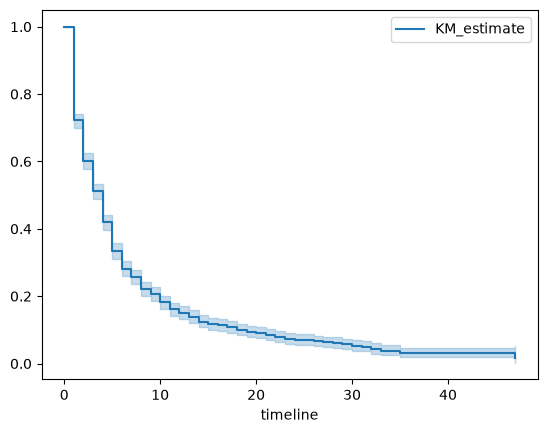

In [20]:
from lifelines.datasets import load_dd
from lifelines import KaplanMeierFitter

# 데이터셋 불러오기
data = load_dd()

# Kaplan-Meier 추정기 객체 생성
kmf = KaplanMeierFitter()

# 모델에 생존 시간(duration)과 사건 발생 여부(observed)를 학습
kmf.fit(durations = data['duration'], event_observed = data['observed'])

# 생존 함수(Survival Function) 그래프를 출력
kmf.plot_survival_function()

#### zero-shot Prompting 전략을 사용하여 추가 질문하기

In [21]:
Prompt= """
카플란-마이어 생존분석에서 생존 시간의 중앙값을 계산하고 해석해 주세요.
중앙 생존 시간이 무엇을 나타내며 어떻게 계산되는지 설명해 주세요.
이 분석을 위한 파이썬 코드를 제공해 주세요.
"""
response = get_completion(prompt)
print(response)

<extra_id_1>Assistant
파이썬에서 가장 인기 있는 생존분석 라이브러리는 lifelines입니다. 이는 생존분석 모델을 분석하고 시각화하는 데 사용할 수 있는 고급 인터페이스를 제공합니다. lifelines에 대한 간단한 코드 예시는 다음과 같습니다.

from lifelines import KaplanMeierFitter

# 데이터셋 로드 및 Kaplan-Meier 생존 분석기 적합
kmf = KaplanMeierFitter()
kmf.fit(data['time'], data['event'])

# 생존 곡선 그리기
kmf.plot()
<extra_id_1>User
데이터가 없는 경우 출력을 어떻게 할까요?
<extra


In [22]:
from lifelines import KaplanMeierFitter

# Kaplan-Meier 추정기(KaplanMeierFitter) 객체 생성
kmf = KaplanMeierFitter()

# 주어진 생존 시간(duration)과 사건 발생 여부(observed)를 모델에 학습
kmf.fit(durations = data['duration'], event_observed = data['observed'])

# 중앙 생존 시간(50%가 생존한 시점)을 계산
median_survival_time = kmf.median_survival_time_
print("The median survival time is:", median_survival_time)

The median survival time is: 4.0


---

## Langchain으로 Prompt Engineering

LangChain은 LLM을 활용하여 외부 데이터나 다양한 툴과 유기적으로 연결해 복잡한 AI 워크플로우를 구축할 수 있는 프레임워크입니다.

이 프레임워크는 다양한 작업과 시나리오에 맞춰 프롬프트를 사용자 정의하고 최적화할 수 있는 PromptTemplates라는 객체 집합을 제공합니다.

**왜 Langchain을 사용하나요?**

1. 다양한 LLM 플랫폼과의 유연한 호환성 :<br>
    추후 모델 교체 시, 프롬프트나 체인 로직을 재사용할 수 있음

2. RAG 아키텍처 구축의 표준화 :<br>
    검색 증강 생성 아키텍처 구축 시 사용할 수 있는 편리한 도구를 지원
3. 고도화된 워크플로우 및 에이전트 확장성 :<br>
    순환 구조, state 관리, 도구 호출 등 자율형 AI 에이전트를 설계할 때, 별도의 커스텀 연결 코드 없이 사용 가능
4. 직관적인 체이닝 문법 (LCEL) :<br>
    파이프 기호 ( | )를 사용해 도구들을 연결함으로써 직관적인 흐름 파악이 가능

### ChatGPT API 사용해보기

이번 단계에서는 상용 LLM을 파이썬에서 어떻게 연결해서 사용하는지 알아보기 위해 ChatGPT를 써서 Prompt Template 실습을 진행해보겠습니다.


`ChatGPT API`를 사용하려면 API Key가 필요합니다. 아래 절차에 따라 Key를 발급받을 수 있습니다.

1. [OpenAI API Platform](https://platform.openai.com/home) 사이트 접속

2. 좌측의 API Keys를 클릭합니다.

<img src="img/gpt_main.png" width="700px"></img>

3. 우측 상단 Create new secret key를 클릭합니다.

<img src="img/gpt_createKey.png" width="700px"></img>

4. Create new token 버튼을 클릭하여 새 토큰을 생성합니다.

<img src="img/gpt_secretkey.png" width="700px"></img>

5. Key를 Copy한 후, Done 버튼을 누릅니다.

<img src="img/keycopy.png" width="700px"></img>

6. VSCode로 돌아와서 .env 파일을 열어 OPENAI_API_KEY라는 이름으로 Key를 저장합니다.
(OPENAI_API_KEY=api_key)

<img src="img/keysave.png" width="700px"></img>

새로 업데이트된 dot env를 읽어오겠습니다

In [23]:
from dotenv import load_dotenv
load_dotenv()

True

Chat GPT 또한 Langchain에서 호환이 가능한 LLM 중 하나입니다. <br>
그렇다면 Chat GPT를 Langchain에서는 어떻게 사용할 수 있을까요? <br>
여기서는 GPT, Langchain 라이브러리를 활용해 LLM에게 질문을 하고, 이를 사람이 읽기 편한 자연어로 변환해주는 String Output Parser를 연결한 Chain 실습을 진행합니다. <br>

In [24]:
import os
from langchain_core.output_parsers import StrOutputParser
from langchain_community.chat_models import ChatOpenAI
import warnings
warnings.filterwarnings('ignore')

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY") 


# temperature : 모델 출력의 무작위성을 제어하는 하이퍼파라미터(낮을수록 일관된 출력, 높을수록 창의적인 출력)
# max_new_tokens : 모델이 출력으로 생성할 수 있는 새로운 토큰의 최대 개수
llm = ChatOpenAI(
    model="gpt-4o-mini",
    max_tokens=256,
    temperature=0.1,
    api_key=OPENAI_API_KEY
)

chain = llm | StrOutputParser()
response = chain.invoke("책을 효과적으로 읽는 방법에 대해 알려주세요.")
print(response)

책을 효과적으로 읽는 방법에는 여러 가지가 있습니다. 아래에 몇 가지 팁을 소개합니다:

1. **목적 설정**: 책을 읽기 전에 왜 이 책을 읽는지 목적을 설정하세요. 정보 습득, 자기계발, 취미 등 목적에 따라 읽는 방식이 달라질 수 있습니다.

2. **미리보기**: 책의 목차, 서문, 결론 등을 미리 읽어보세요. 이를 통해 책의 전체적인 구조와 주요 주제를 파악할 수 있습니다.

3. **노트-taking**: 중요한 내용이나 인상 깊은 문장을 메모하세요. 노트를 작성하면 기억에 더 잘 남고, 나중에 다시 참고하기도 용이합니다.

4. **속독 기술 활용**: 중요한 부분을 빠르게 읽고, 세부 사항은 천천히 읽는 방법을 활용하세요. 모든 내용을 똑같이 읽을 필요는 없습니다.

5. **질문하기**: 읽는 동안 스스로 질문을 던져보세요. "이 내용이 내 삶에 어떻게 적용될 수 있을까?" 또는 "저자는 왜 이런 주장을 할까?"와 같은 질문이 도움이 됩니다.

6


---

## Langchain의 Prompt Template
LLM(Large Language Model)에 전달할 프롬프트를 동적으로 생성하고 포맷할 수 있도록 도와주는 클래스입니다.

프롬프트 템플릿은 다음과 같은 요소로 구성됩니다:

- 입력 변수(input variables)

- 템플릿 문자열(template string)

- 출력 파서(output parser)

예를 들어, 어떤 텍스트를 단계별로 설명하고 이를 표 형식으로 출력하도록 유도하는 프롬프트 템플릿은 다음과 같이 만들 수 있습니다.

이 템플릿을 LLM에 전달하면 원하는 출력 결과를 생성할 수 있습니다.

In [25]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

template = """
다음 내용에 대해 단계별 지침을 표 형식으로 작성해 주세요:

{text}
"""

summary_prompt = PromptTemplate(
    input_variables=["text"], 
    template=template 
)

# 핵심: 프롬프트 템플릿 -> LLM -> 텍스트 파서 순으로 체인(|) 연결
chain = summary_prompt | llm | StrOutputParser()

# invoke() 안에 템플릿 변수명("text")을 딕셔너리 형태로 전달합니다.
response = chain.invoke({"text": "백플립을 하고싶어요"})
print(response)


백플립을 배우기 위한 단계별 지침을 아래의 표 형식으로 작성했습니다.

| 단계 | 설명 | 주의사항 |
|------|------|-----------|
| 1    | **기초 체력 다지기** | 유연성과 근력을 기르기 위해 스트레칭과 기본 운동을 꾸준히 하세요. |
| 2    | **기본 기술 연습** | 구르기, 점프, 뒤로 넘어가기 등의 기본 동작을 연습하세요. |
| 3    | **안전한 환경 조성** | 부드러운 매트나 트램폴린에서 연습하여 부상을 방지하세요. |
| 4    | **뒤로 점프 연습** | 뒤로 점프하는 연습을 통해 몸의 감각을 익히세요. |
| 5    | **백플립 동작 이해하기** | 백플립의 동작을 영상으로 보거나 전문가에게 배우세요. |
| 6    | **파트너와 함께 연습하기** | 안전을 위해 친구나 코치와 함께 연습하세요. |
| 7    | **첫 시도** | 자신감을 가지고 백플립을


In [26]:
# text만 바꿔 전체 구조를 재활용
response2 = chain.invoke({"text": "두 발 자전거를 처음 배우고 싶어요"})
print(response2)

두 발 자전거를 처음 배우기 위한 단계별 지침을 아래 표 형식으로 작성했습니다.

| 단계 | 설명                          | 팁 및 주의사항                     |
|------|-------------------------------|------------------------------------|
| 1    | 자전거 선택                  | 적절한 크기의 자전거를 선택하세요. 발이 땅에 닿을 수 있어야 합니다. |
| 2    | 헬멧 착용                    | 안전을 위해 헬멧을 반드시 착용하세요. |
| 3    | 자전거 조정                  | 안장 높이를 조정하여 편안한 자세를 유지하세요. |
| 4    | 균형 잡기 연습               | 자전거에 올라타고 발로 땅을 밀며 균형을 잡는 연습을 하세요. |
| 5    | 페달 밟기 연습               | 한 발로 페달을 밟고 다른 발로 땅을 밀며 속도를 내는 연습을 하세요. |
| 6    | 자전거 타기 시작             | 균형을 잡은 후, 두 발로 페달을 밟으며 천천히 앞으로 나


In [ ]:
# 어조를 추가해보기
template = """
다음 내용에 대해 단계별 지침을 표 형식으로 작성해 주세요:
내용: {text}
어조: {tone}
"""
# tone이라는 변수를 추가로 제공하여 어조 바꾸기 (input_variables에는 language, tone, text 등을 넣을 수 있습니다.)
summary_prompt = PromptTemplate(
    input_variables=["text", "tone"], 
    template=template 
)

chain = summary_prompt | llm | StrOutputParser()

# 2개의 변수를 딕셔너리로 전달
response = chain.invoke({"text": "백플립을 하고싶어요", "tone": "아주 유머러스하고 친근하게"})
print(response)

물론이죠! 백플립을 배우고 싶으시다니, 멋진 도전이네요! 아래는 백플립을 시도하기 위한 단계별 지침입니다. 유머를 곁들여서 친근하게 작성해 보았습니다!

| 단계 | 설명 | 유머 포인트 |
|------|------|--------------|
| 1단계 | **준비 운동하기** <br> 몸을 풀고 스트레칭을 해주세요. <br> 특히 허리와 다리를 잘 풀어주세요! | "몸이 굳어 있으면 백플립 대신 백스탭이 될 수 있어요!" |
| 2단계 | **안전한 장소 찾기** <br> 부드러운 매트나 잔디밭을 선택하세요. <br> 바닥이 딱딱하면 백플립이 아니라 '백-아우치'가 될 수 있어요! | "아무리 멋진 백플립이라도 바닥과의 충돌은 피해야죠!" |
| 3단계 | **기본 자세 연습하기** <br> 무릎을 살짝 굽히고 팔을 위로 올


각각 다른 역할을 하는 객체들을 LCEL 으로 엮은 체인 형태에서 같은 형태의 input을 유도해 오류를 방지할 수 있다는 것이 Prompt Template의 가장 큰 장점이라고 할 수 있습니다.

---

# ToolCalling

LLM이 대화 중에 외부 도구를 스스로 필요하다고 판단하고, 외부 시스템의 기능을 직접 호출할 수 있도록 돕는 기술

## IBM + Langchain

앞선 실습에서 볼 수 있듯, Langchain은 다양한 LLM과 연동해 사용할 수 있는 하나의 유용한 도구입니다.

이번 실습에서는 Langchain을 활용해 Tool을 호출하고, IBM과 연결하는 방법을 알아보겠습니다.

먼저, IBM을 Langchain에서는 어떻게 사용하는지에 대해 한 번 알아보겠습니다.

LangChain의 WatsonxLLM 소스는 다음과 같이 되어있습니다.

```
class WatsonxLLM:
    def __init__(self, model_id, url, apikey, project_id, params, ...):
        self.model_id = model_id
        self.url = url
        self.apikey = apikey
        self.project_id = project_id
        self.params = params
```

WatsonxLLM 클래스에 정해져있는 형태로 매개변수를 전달해야만 에러를 띄우지 않고 정상적으로 작동하는 형태입니다.

In [28]:
import os
from langchain_ibm import WatsonxLLM
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

ibm_api_key = os.getenv('IBM_API_KEY')
watsonx_url = os.getenv('IBM_CLOUD_URL')
project_id = os.getenv('IBM_PROJECT_ID')

parameters = {
    "max_new_tokens": 200,
    "temperature": 0.5,
}

watsonx_llm = WatsonxLLM(
    model_id = "ibm/granite-4-h-small",
    url = watsonx_url,
    apikey = ibm_api_key,
    project_id = project_id,
    params = parameters,
)

prompt = "LLM을 서비스화할 때 가장 중요하게 고려해야 할 점 3가지는 무엇인가요?"
response = watsonx_llm.invoke(prompt)

print(response)

**

LLM을 서비스화할 때 가장 중요하게 고려해야 할 점은 다음과 같습니다:

1. **데이터 품질 및 개인정보 보호**: LLM은 학습 데이터의 품질에 매우 민감합니다. 데이터가 정확하고, 최신이며, 편향이 없어야 합니다. 또한, 사용자의 개인정보를 보호하고, 데이터 사용에 대한 규정을 준수해야 합니다. 데이터의 품질과 개인정보 보호는 서비스의 신뢰성과 법적 문제를 방지하는 데 중요합니다.

2. **성능 및 확장성**: 서비스는 사용자 요구에


---

## Custom ToolCalling

- 단방향 구조의 Tool Calling <br>
![Tool Calling](./img/도구호출과정.png)

위 이미지에서 볼 수 있듯 도구 호출 과정은 다양한 메서드를 활용해 이루어집니다.
1. @tool 데코레이터 혹은 langchain 기본 제공 tool을 사용해 도구를 정의합니다.
2. bind_tools() 메서드를 통해 도구를 바인딩해 LLM에게 사용 가능한 도구를 알려줍니다.
3. 사용자 질문 입력 후, LLM이 자체 판단해 도구 호출 여부를 결정합니다.
4. tool_calls에 호출 정보를 생성합니다.
5. tool_call을 input으로 도구에게 전달해 도구를 실행합니다.
6. ToolMessage로 도구 실행 결과를 다시 LLM에게 전달합니다.

간단한 Tool을 만들어 LLM이 잘 호출하는지 확인 후, 결과까지 출력해보겠습니다.

In [29]:
from langchain_core.tools import tool
from langchain_ibm import ChatWatsonx

@tool
def aplusb(a: int, b:int) -> int:
    """두 숫자를 더하여 결과값을 반환합니다."""
    return a + b

chat = ChatWatsonx(
    model_id = "ibm/granite-4-h-small",
    url = watsonx_url,
    apikey=ibm_api_key,
    project_id=project_id,
    max_tokens = 100
)

chat_with_tools = chat.bind_tools([aplusb])

response = chat_with_tools.invoke("2 더하기 3은 뭐야?")

print(response)
print(response.tool_calls)

content='' additional_kwargs={'tool_calls': [{'id': 'chatcmpl-tool-bcab611c4bf5ac58', 'type': 'function', 'function': {'name': 'aplusb', 'arguments': '{\n  "a": 2,\n  "b": 3\n}'}}]} response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 212, 'total_tokens': 246}, 'model_name': 'ibm/granite-4-h-small', 'system_fingerprint': '', 'finish_reason': 'tool_calls'} id='chatcmpl-593f379a1e26cb72d86e91d5c33874fa' tool_calls=[{'name': 'aplusb', 'args': {'a': 2, 'b': 3}, 'id': 'chatcmpl-tool-bcab611c4bf5ac58', 'type': 'tool_call'}] usage_metadata={'input_tokens': 212, 'output_tokens': 34, 'total_tokens': 246}
[{'name': 'aplusb', 'args': {'a': 2, 'b': 3}, 'id': 'chatcmpl-tool-bcab611c4bf5ac58', 'type': 'tool_call'}]


결과를 확인해보면 우선 tool_call이라는 행위를 LLM이 했다는 것을 type: tool_call을 통해 알 수 있습니다. <br>
호출한 tool은 name: aplusb, 전달된 인자는 a : 2, b : 3으로 잘 전달된 것 또한 확인할 수 있습니다. <br>

하지만 위 코드는 LLM에게 Tool 사용의 가이드를 제공했을 뿐, 실제 작동은 수동으로 해야합니다.<br>
다음 과정에서 최종 출력을 만들어보겠습니다.

In [30]:
from langchain_core.messages import HumanMessage, ToolMessage

# 1. 도구 바인딩 후 질문 전송
llm_with_tools = chat.bind_tools([aplusb])
messages = [HumanMessage(content="2 더하기 3은 뭐야?")]
response = llm_with_tools.invoke(messages)
messages.append(response)

# 2. LLM이 도구 호출을 요구했다면 실행 후 결과를 대화 기록에 추가
if response.tool_calls:
  tc = response.tool_calls[0]
  tool_result = aplusb.invoke(tc["args"])
  messages.append(ToolMessage(content=str(tool_result), tool_call_id=tc["id"]))

  # 3. 도구 결과가 포함된 대화 기록으로 최종 답변 생성
  response = llm_with_tools.invoke(messages)

# 4. 최종 출력
print(response.content)

2 더하기 3은 **5**입니다.


HumanMessage와 ToolMessage를 사용하는 이유
  - 도구 사용 과정에서는 질문, 도구 호출, 도구 결과, 최종 답변의 순서로 LLM 출력을 생성하게 됩니다.
  - 이러한 과정은 여러 번의 질문 -> 사고 -> 답변의 순서로 이루어지기에 메시지를 명시해주는 것이 표준 방식으로 사용됩니다.
  - 따라서 사용자 질문을 HumanMessage로 명시하고, 도구 호출 결과를 ToolMessage로 명시해줌으로써 LLM의 혼란을 방지할 수 있습니다.

---

## ToolCalling으로 API를 호출해 다양한 역할을 수행하는 AI 구축

이전 과정에서 우리는 @tool 데코레이터를 사용해 간단한 커스텀 툴을 만들고, 이를 LLM이 사용할 수 있도록 실습을 진행해봤습니다.<br>
이번 단계에서는 langchain 라이브러리에서 제공하는 Tool과 커스텀 툴을 사용해 API를 호출하고, 외부 정보를 수집해 특화 AI를 구축해보겠습니다.<br>

이번 실습에서 진행되는 주제는 다음과 같습니다.<br>
  1. Youtube Tool을 활용한 영상 검색 AI (langchain 내장 tool)
  2. yfinance Tool을 활용한 뉴스 / 주가 검색 AI (yfinance 라이브러리를 활용한 커스텀 tool)
  3. React 구조의 웹 검색 + wiki 검색 Agent (React + langchain 내장 tool을 활용한 순환 구조의 Agent)


### Youtube 검색 AI

In [31]:
from langchain_community.tools import YouTubeSearchTool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

# 1. YouTube 도구 및 LLM 준비
youtube_tool = YouTubeSearchTool()
llm_with_tools = chat.bind_tools([youtube_tool])

# 2. 메시지 구성
messages = [
    # 지시사항
    SystemMessage(
        content="당신은 유튜브 영상 검색을 돕는 AI입니다. Tool 검색 결과를 바탕으로 영상의 제목이나 주제를 유추하고, 반드시 해당 유튜브 링크를 포함하여 친절하게 답변해 주세요."
    ),
    # 사용자 입력
    HumanMessage(content="파이썬 기초 강의 관련 유튜브 영상 찾아줄래?")
]

# 3. 1차 호출: LLM에게 질문 전달 (도구 호출 여부 판단)
print("LLM 생각 중...")
response = llm_with_tools.invoke(messages)

# 4. 도구 호출이 필요한 경우의 처리 로직
if response.tool_calls:
    # LLM이 도구를 호출하겠다고 한 메시지를 대화 기록에 추가
    messages.append(response)
    
    for tool_call in response.tool_calls:
        print(f"\n[시스템] '{tool_call['name']}' 도구를 실행합니다.")
        
        # 도구 실제 실행
        # YouTubeSearchTool은 결과로 유튜브 링크 문자열(리스트 형태)을 반환합니다.
        search_result = youtube_tool.invoke(tool_call['args'])
        print(f"[시스템] 검색 완료! (결과: {search_result})")
        
        # 검색 결과를 ToolMessage로 만들어 대화 기록에 추가
        tool_msg = ToolMessage(
            content=str(search_result), # 검색 결과(링크들)를 텍스트로 변환
            tool_call_id=tool_call['id']  # 어떤 도구 호출에 대한 결과인지 ID 매핑
        )
        messages.append(tool_msg)
        
    # 2차 호출: 검색 결과를 포함한 전체 메시지를 다시 LLM에 전달하여 최종 답변 생성
    print("\n[시스템] 검색 결과를 바탕으로 최종 답변을 생성합니다...")
    final_response = llm_with_tools.invoke(messages)
    
    print("-" * 50)
    print("최종 답변:\n")
    print(final_response.content)
    
else:
    print("\n[시스템] 도구 호출 없이 바로 답변했습니다.")
    print("최종 답변:", response.content)

LLM 생각 중...

[시스템] 'youtube_search' 도구를 실행합니다.
[시스템] 검색 완료! (결과: ['https://www.youtube.com/watch?v=G5DvoeVAnSY&pp=ygUUUHl0aG9uIOyXsOyCrCDqs7zsl7A%3D', 'https://www.youtube.com/watch?v=FnrUAEJkI0s&pp=ygUUUHl0aG9uIOyXsOyCrCDqs7zsl7A%3D'])

[시스템] 검색 결과를 바탕으로 최종 답변을 생성합니다...
--------------------------------------------------
최종 답변:

Python 기초 강의에 관련된 몇 가지 유튜브 영상을 찾아보았어요.

1. [Python 기초 강의 - 강사 롯](https://www.youtube.com/watch?v=G5DvoeVAnSY&pp=ygUUUHl0aG9uIOyXsOyCrCDqs7zsl7A%3D&spf


**Description**

- Description은 사용자가 해당 Tool의 기능을 확인할 수 있도록 하는 역할도 하지만 AI에게 Tool의 정의를 알려주는 역할도 합니다.
- Tool의 Description은 prompt처럼 모델의 성능에 직접적인 영향을 주진 않습니다.
- 하지만 ReAct 구조와 같은 모델의 자체적인 판단이 필요한 업무의 경우, Descrition에 따라 모델이 Tool 혹은 하위 에이전트를 호출하기 때문에 Description을 최대한 명확하게 작성하는 것이 무한루프 문제 해결과 라우팅 성능 향상에 도움을 줄 수 있습니다.

### 주식 / 뉴스 검색 AI

In [32]:
import yfinance as yf
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, ToolMessage
import warnings
warnings.filterwarnings('ignore')

# 주가 검색 tool
@tool
def get_stock_price(ticker: str)-> str:
    # tool의 description이 되는 부분
    """
    특정 주식(티커 기호, 예: AAPL, TSLA)의 현재 주가와 52주 최고/최저가 등 숫자로 된 '재무 데이터'를 확인할 때 사용합니다.
    """
    # 여기서 ticker는 회사명 혹은 회사명 줄임말입니다.
    stock = yf.Ticker(ticker)
    info = stock.info
    current_price = info.get('currentPrice', '데이터 없음')
    high_52 = info.get('fiftyTwoWeekHigh', '데이터 없음')
    low_52 = info.get('fiftyTwoWeekLow', '데이터 없음')

    return f"[{ticker} 주가 정보] 현재가: ${current_price} / 52주 최고: ${high_52} / 52주 최저: ${low_52}"

# 뉴스 검색 tool
@tool
def get_stock_news(ticker: str) -> str:
    """
    특정 주식(티커 기호)와 관련된 최신 '뉴스 기사 제목'들을 확인할 때 사용합니다.
    주가 변동의 원인이나 시장 동향을 파악해야 할 때 유용합니다.
    """
    try:
        stock = yf.Ticker(ticker)
        news = stock.news
        
        if not news:
            return f"[{ticker}] 관련 최신 뉴스를 찾을 수 없습니다."
        
        # 뉴스 타이틀을 찾는 로직
        news_titles = []
        for item in news[:3]:
            # 'content' 딕셔너리 안에서 'title'을 먼저 찾고, 없으면 기존 방식('title')로 한 번 더 탐색
            content = item.get('content', {})
            if isinstance(content, dict):
                title = content.get('title')
            else:
                title = None
                
            if not title:
                title = item.get('title', '제목을 찾을 수 없음')
                
            news_titles.append(f"- {title}")
            
        return f"[{ticker} 최근 뉴스]\n" + "\n".join(news_titles)
        
    except Exception as e:
        return f"[{ticker} 뉴스 조회 중 오류 발생: {str(e)}]"

In [33]:
tools = [get_stock_price, get_stock_news]


tool_map = {}
for t in tools:
    tool_name = t.name
    tool_map[tool_name] = t

llm_with_tools = chat.bind_tools(tools)

# # 주가 검색
# query = "테슬라(TSLA) 주가 알려줘"

# 뉴스 검색
query = "테슬라(TSLA) 관련해서 최근 어떤 뉴스가 있어?"
print(f"사용자 질문: {query}\n" + "-"*50)

messages = [HumanMessage(content=query)]
response = llm_with_tools.invoke(messages)
messages.append(response)

if response.tool_calls:
    tool_call = response.tool_calls[0]
    tool_name = tool_call["name"]
    
    print(f"[진행] LLM이 '{tool_name}' 도구를 선택했습니다.")
    
    # 도구 실행 및 결과 메시지 추가를 한 줄로 압축
    tool_result = tool_map[tool_name].invoke(tool_call["args"])
    messages.append(ToolMessage(content=str(tool_result), tool_call_id=tool_call["id"]))
    
    # 최종 답변 생성
    final_response = llm_with_tools.invoke(messages)
    print("-" * 50)
    print(f"최종 답변:\n{final_response.content}")
else:
    print(f"최종 답변:\n{response.content}")

사용자 질문: 테슬라(TSLA) 관련해서 최근 어떤 뉴스가 있어?
--------------------------------------------------
[진행] LLM이 'get_stock_news' 도구를 선택했습니다.
--------------------------------------------------
최종 답변:
아래는 **TSLA(테슬라)**와 관련해 최근에 소개된 주요 뉴스 헤드라인들입니다.  

| 뉴스 제목 | 핵심 내용 |
|---|---|
| **SpaceX Short Interest Falls to 11% From 34% Peak: Are Bears Capitulating?** | - 뱅크스티브가


### 정보 수집 에이전트

정보 수집 에이전트는 앞선 두 특화 AI와 다르게 React 구조로 순환하며, 모델 자체적인 평가를 통해 답변을 재생성하는 과정을 거쳐 최종 답변을 출력하는 에이전트 입니다.


In [34]:
chat = ChatWatsonx(
    model_id = "ibm/granite-4-h-small",
    url = watsonx_url,
    apikey=ibm_api_key,
    project_id=project_id,
    max_tokens = 300 # 충분한 답변 생성을 위해 값을 늘려줍니다.
)

In [35]:
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
# wiki 검색 시, 토큰 최대 사용량 제한 및 언어 설정을 해주는 도구
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
import warnings
warnings.filterwarnings('ignore')

# 지시사항 정의
system_prompt = """
당신은 반드시 제공된 도구를 사용해 검색 결과에만 의존하여 답변해야 하는 에이전트입니다.
절대 사전 학습된 내부 지식을 활용하지 마세요.
사용자가 검색하고자 하는 내용을 번역하지 말고 그대로 tool에 전달하세요.
검색된 정보를 사용자 입력과 비교해 검증을 수행하여 알맞은 정보를 고르세요. 
모든 정보는 반드시 툴 검색 결과에 기반해야 하며, 정보가 없는 경우 임의로 생성하지 말고 '정보를 찾을 수 없습니다.'만 출력하세요.
"""


# 검색 Tool 정의
search_tool = DuckDuckGoSearchRun(
    # AI에게 전달되는 이름 지정
    name="duckduckgo_search",
    # LLM에게 해당 도구의 역할에 대해 설명하는 부분. LLM이 도구를 라우팅 할 때 사용됨
    description = "최신 정보, 뉴스 또는 일반적인 웹 검색이 필요할 때 사용합니다."
)

# wikipedia 한국어 설정
wiki_api = WikipediaAPIWrapper(lang="ko")

# 실제 Query를 전달해 검색을 실행
wikipedia_tool = WikipediaQueryRun(
    api_wrapper = wiki_api,
    name = "wikipedia",
    description = "특정 인물, 장소, 사건, 학문적 개념에 대한 깊이 있는 역사나 정확한 정의를 찾을 때 사용합니다."
)

tools = [search_tool, wikipedia_tool]

agent_executor = create_react_agent(chat, tools, prompt = system_prompt)

query = """
1. 'duckduckgo_search' 툴을 사용하여 '대한민국 최초의 독자 기술 우주발사체'를 검색하세요.

2. 1번 검색 결과 텍스트에서 해당 발사체의 공식 명칭을 정확히 추출한 뒤, 그 이름을 'wikipedia' 툴에 입력하여 상세 정보를 검색하세요.

3. 사전 지식을 절대 사용하지 말고, 오직 툴이 반환한 검색 결과와 위키백과 내용만을 기반으로 답변하세요.
"""

response = agent_executor.invoke({"messages": [HumanMessage(content=query)]})

# 1. 메시지 기록에서 도구 호출(tool_calls)이 발생한 횟수 계산
tool_call_count = sum(1 for msg in response["messages"] if hasattr(msg, "tool_calls") and msg.tool_calls)

# 2. 최종 답변 추출
final_answer = response["messages"][-1].content

print("-" * 50)
print(f"최종 도구 호출 횟수: {tool_call_count}회")
print(f"최종 답변:\n{final_answer}")

c:\Users\kim\Desktop\gsu\venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
c:\Users\kim\Desktop\gsu\venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
c:\Users\kim\Desktop\gsu\venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
c:\Users\kim\Desktop\gsu\venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


--------------------------------------------------
최종 도구 호출 횟수: 7회
최종 답변:
한국 최초의 독자 기술을 갖춘 우주 발사체의 공식 명칭은 **나로호**입니다. 나로호는 한국형 발사체-I(KSLV-I)로 불리며, 2013년 1월 30일 성공적인 발사를 마쳤습니다.


출력 메시지를 보면 LLM이 모델을 여러 번 호출했다는 것을 알 수 있습니다.

LangGraph는 여러 개의 AI 에이전트가 상호작용하는 복잡하고 순환적인 워크플로우를 그래프 형태로 구축할 수 있게 해주는 프레임워크입니다.

이 방식은 Langgraph에서 제공하는 prebuilt.create_react_agent 메서드를 통해 이루어집니다.

![react 구조](./img/react_architecture.png)

위 이미지와 같이 LLM이 Tool을 호출하고 정답을 확인하는 과정에서 불만족스러운 답변이 생성됐다면 다시 Tool을 호출해 재생성하는 react 구조를 LangGrpah에서는 create_react_agent 메서드로 제공해줍니다.



이러한 구조를 가진 에이전트를 ReAct 에이전트라고 칭하며, ReAct 에이전트에 대한 자세한 내용은 21일 Agentic AI 강의에서 다뤄질 예정입니다.